In [133]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

Importation des données

In [134]:
df = pd.read_csv(r"..\data\en.openfoodfacts.org.products.csv.gz", sep="\t", encoding='utf-8', nrows=10000)

C:\Users\julie\AppData\Local\Temp\ipykernel_39628\3062298247.py:1: DtypeWarning: Columns (0: abbreviated_product_name, 1: packaging_text, 2: no_nutrition_data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"..\data\en.openfoodfacts.org.products.csv.gz", sep="\t", encoding='utf-8', nrows=10000)


In [135]:
df.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,...,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1740205422,2025-02-22T06:23:42Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1673620307,2023-01-13T14:31:47Z,1750061386,2025-06-16T08:09:46Z,bodysupport,1750061386,2025-06-16T08:09:46Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,114,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1580066482,2020-01-26T19:21:22Z,1751035658,2025-06-27T14:47:38Z,teolemon,1751035658,2025-06-27T14:47:38Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,431,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1714301712,2024-04-28T10:55:12Z,1714301721,2024-04-28T10:55:21Z,kiliweb,1714301721,2024-04-28T10:55:21Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,105,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1572117743,2019-10-26T19:22:23Z,1738073570,2025-01-28T14:12:50Z,NaN,1743653496,2025-04-03T04:11:36Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [136]:
df.shape

(10000, 211)

In [137]:
with open("colonnes.txt", "w") as f:
    for col in df.columns:
        f.write(col + "\n") ### ça créer un fichier texte avec le nom de TOUTES les colonnes du dataframe

#il y a une colomne nomée nutriscore_grade avec des valeurs de type objet (str)


In [138]:
print(df["nutriscore_grade"].dtype)

print(df["nutriscore_grade"].unique())

print(df["nutriscore_grade"].value_counts())

#on a ~ 30% de nos aliments qui ont un nutriscore connu. 
#on train sur ces 30% et on test sur les autres 70% pour prédire le nutriscore des aliments qui n'ont pas de nutriscore connu.
#puis on vérifie si les scores calculés sont cohérents avec les autres informations nutritionnelles de l'aliment avec des graphiques. Comme des boxplot pour chaque catégorie (A, B..) en fonction du sucre par exemple. 
#MAIS on peut AUSSI couper les 30% en deux parties, une pour le train et une pour le test, pour évaluer la performance de notre modèle.
#je trouve ça mieux car au moins on a nos score, on peut faire nos training curve etc .. Puis on peut ensuite appliquer le modèle sur les 70% restants pour prédire le nutriscore des aliments qui n'ont pas de nutriscore connu.

str
<StringArray>
['unknown', nan, 'c', 'a', 'not-applicable', 'e', 'd', 'b']
Length: 8, dtype: str
nutriscore_grade
unknown           8455
e                  306
not-applicable     267
d                  209
c                  190
a                  171
b                   89
Name: count, dtype: int64


Spliter les données en deux parties : une pour l'entraînement et une pour le test. Méthode HOLD OUT

In [139]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["nutriscore_grade"])   # nos variables explicatives
y = df["nutriscore_grade"]                   # ce qu'on veut prédire

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#test_size should be between 0.0 and 1.0 and represent the proportion of the dataset to include in the test split.

##la ça prend tout le jeu de données donc pas bien. 
#Il faut le faire sur les 30% des données avec nutriscore connu, donc créons un nouveau dataframe?

In [140]:
#je génère 2 nouveaux dataframes, un avec les aliments qui ont un nutriscore connu et un autre avec ceux qui n'ont pas de nutriscore connu.

# DataFrame avec les nutriscores connus (a, b, c, d, e)
scores_connus = ['a', 'b', 'c', 'd', 'e']
df_connu = df[df['nutriscore_grade'].isin(scores_connus)].copy()

# DataFrame avec le reste (unknown, not-applicable, ou NaN éventuels)
df_inconnu = df[~df['nutriscore_grade'].isin(scores_connus)].copy()

# Vérification rapide
print("Connu :", df_connu.shape)
print("Inconnu :", df_inconnu.shape)
print(df_connu['nutriscore_grade'].value_counts())
print(df_inconnu['nutriscore_grade'].value_counts(dropna=False))

Connu : (965, 211)
Inconnu : (9035, 211)
nutriscore_grade
e    306
d    209
c    190
a    171
b     89
Name: count, dtype: int64
nutriscore_grade
unknown           8455
NaN                313
not-applicable     267
Name: count, dtype: int64


In [141]:
from sklearn.model_selection import train_test_split

features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
            'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
            'fat_100g', 'carbohydrates_100g']

X = df_connu[features]  # Seules CES colonnes sont sélectionnées, tout le reste est ignoré
y = df_connu['nutriscore_grade']    

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#test_size should be between 0.0 and 1.0 and represent the proportion of the dataset to include in the test split.

PREPARATION DES DONNEES

Gérer données manquantes 

In [142]:
#Nettoyage minimal des données
percent_missing = df_connu[features].isnull().sum() * 100 / len(df_connu)
percent_missing.sort_values(ascending=False,inplace=True)

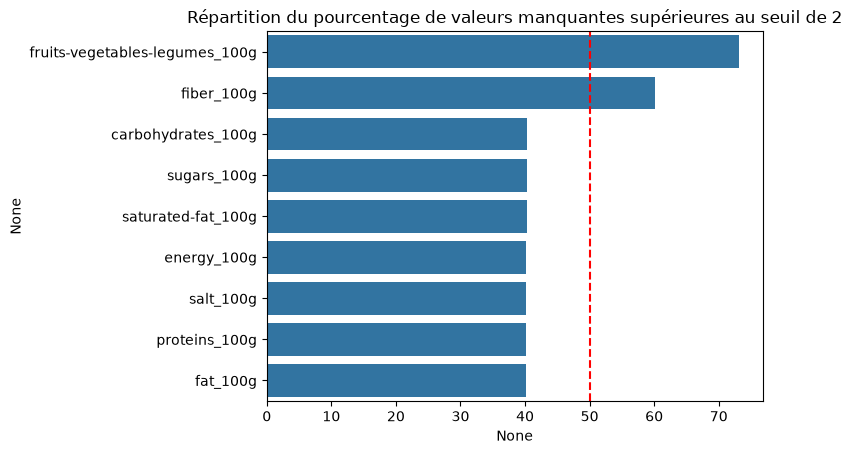

In [143]:
threshold_view = 2

filtered = percent_missing[percent_missing.values > threshold_view]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h');
ax.set_title(f"Répartition du pourcentage de valeurs manquantes supérieures au seuil de {threshold_view}");

threshold = 50

ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")

In [144]:
## On retire les features avec + de 60% de valeurs manquantes

columns_to_drop = percent_missing[percent_missing.values > threshold].index
print(columns_to_drop)

df_restr_8 = df_connu[features + ['nutriscore_grade']].drop(columns=columns_to_drop)

print(df_restr_8.shape)
df_restr_8.head()

Index(['fruits-vegetables-legumes_100g', 'fiber_100g'], dtype='str')
(965, 8)


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g,nutriscore_grade
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c
13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a
18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c
19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,e


In [145]:
mask_complet = X_reduit.dropna().index
print(df_connu.loc[mask_complet, 'nutriscore_grade'].value_counts())


nutriscore_grade
e    158
c    138
d    123
a     89
b     66
Name: count, dtype: int64


In [146]:
#### PLUS TARD :AJOUER DES VARIABLES EXPLICATIVES SUPPLEMENTAIRES POUR AMELIORER LA PREDICTION DU NUTRISCORE

Imputation

In [147]:
from sklearn.impute import SimpleImputer

raw_df_restr_8 = df_restr_8.copy() ##je garde une copie du dataframe avant imputation pour pouvoir comparer les résultats après imputation.


# On sépare les features (à imputer) de la cible
features_restantes = df_restr_8.columns.drop('nutriscore_grade')

imputer = SimpleImputer(strategy='mean')

df_restr_8[features_restantes] = imputer.fit_transform(df_restr_8[features_restantes])

print(df_restr_8.isnull().sum())  # vérification : tout devrait être à 0
df_restr_8.head()

energy_100g           0
saturated-fat_100g    0
sugars_100g           0
salt_100g             0
proteins_100g         0
fat_100g              0
carbohydrates_100g    0
nutriscore_grade      0
dtype: int64


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g,nutriscore_grade
12,1260.654183,4.603838,12.430847,1.128263,9.949508,19.660596,33.235517,c
13,1260.654183,4.603838,12.430847,1.128263,9.949508,19.660596,33.235517,c
14,1260.654183,4.603838,12.430847,1.128263,9.949508,19.660596,33.235517,a
18,1260.654183,4.603838,12.430847,1.128263,9.949508,19.660596,33.235517,c
19,1260.654183,4.603838,12.430847,1.128263,9.949508,19.660596,33.235517,e


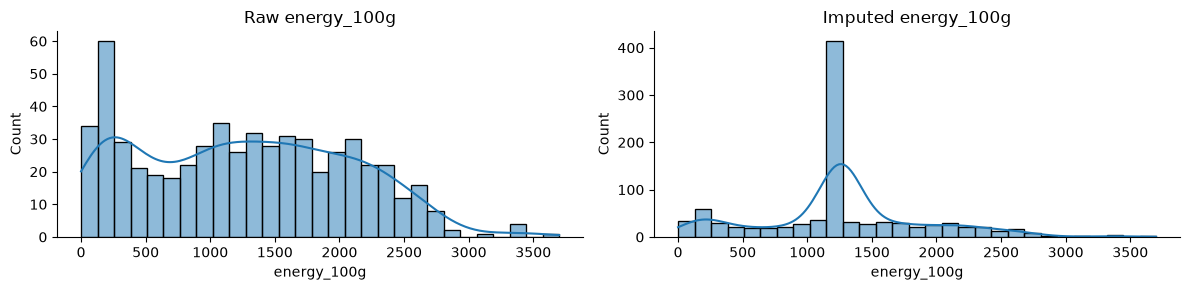

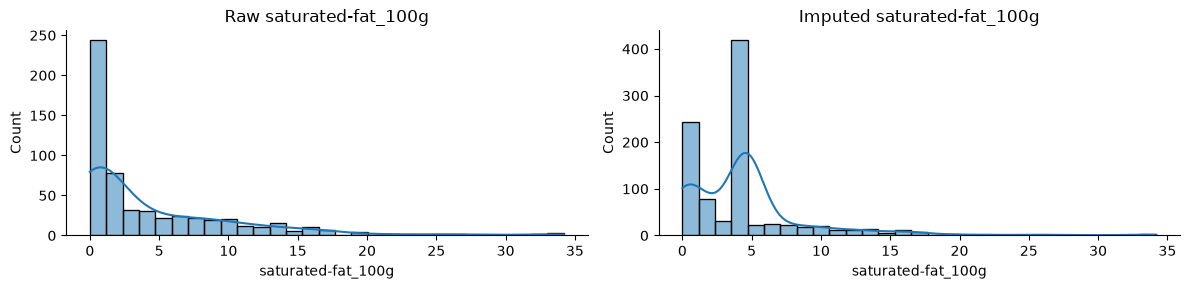

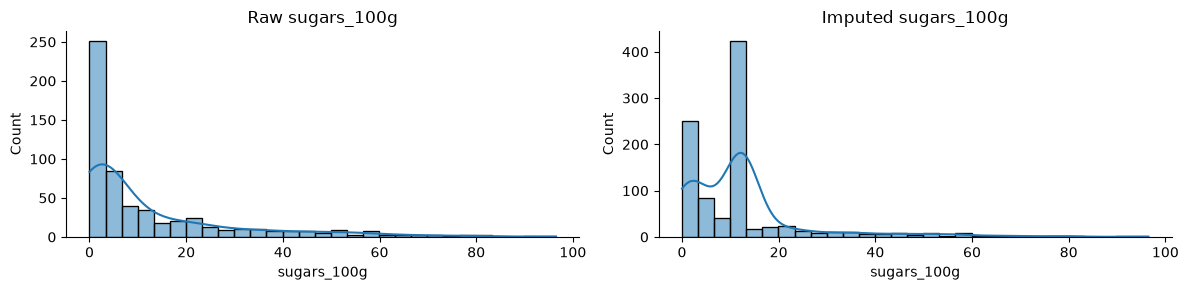

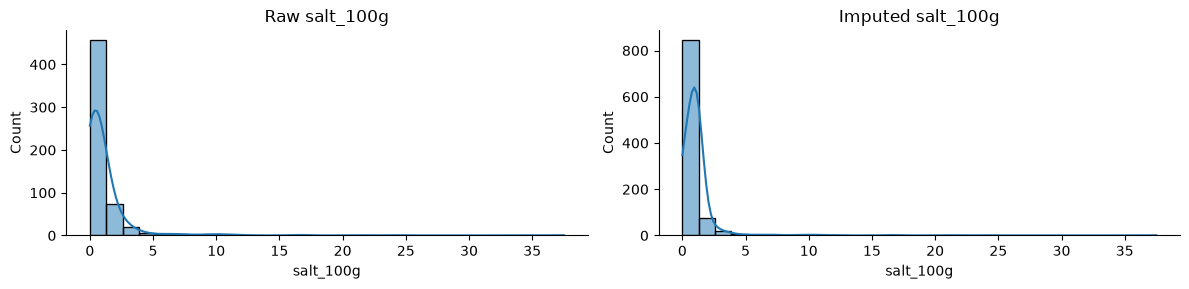

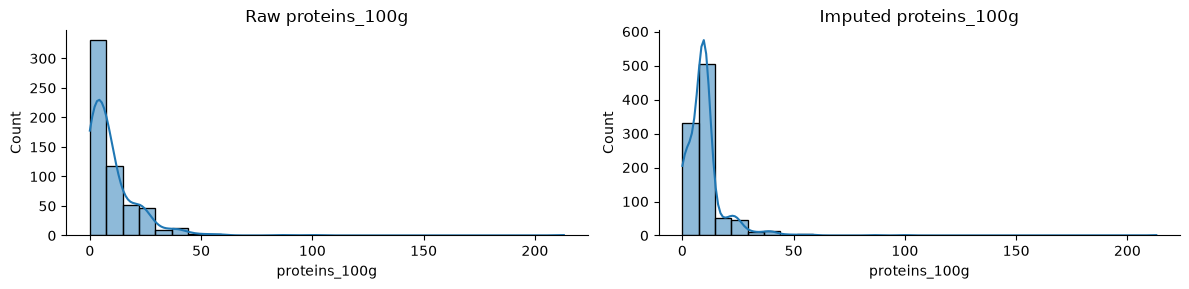

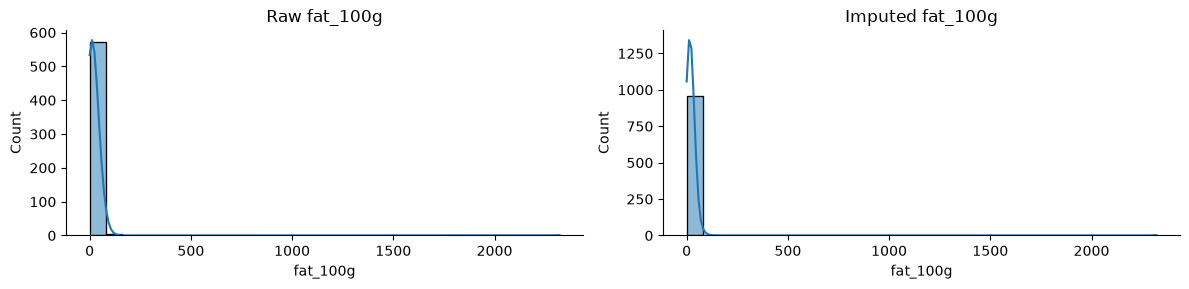

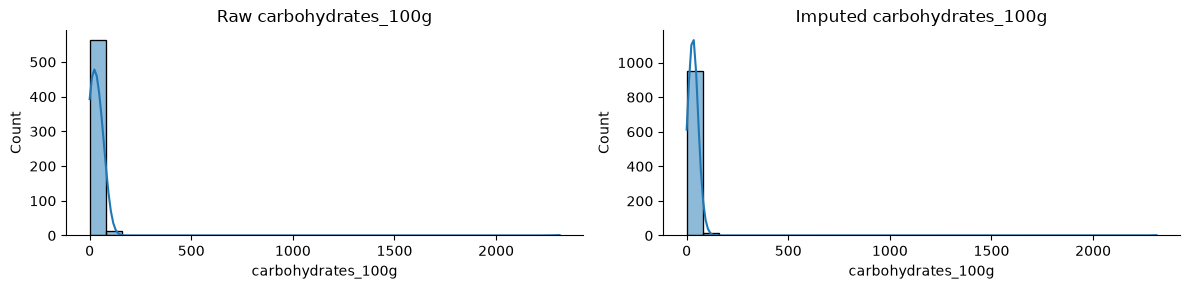

In [148]:
#comparer avant et après imputation pour voir si les valeurs imputées sont cohérentes avec les autres valeurs de la colonne.


def compare_dist(feature, raw_df_restr_8, df_restr_8):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    
    # Bins communs calculés sur la plage combinée des deux distributions
    combined_min = min(raw_df_restr_8[feature].min(), df_restr_8[feature].min())
    combined_max = max(raw_df_restr_8[feature].max(), df_restr_8[feature].max())
    bins = np.linspace(combined_min, combined_max, 30)  # 30 bins, ajustable
    
    ax = axes[0]
    sns.histplot(raw_df_restr_8.loc[:, feature], kde=True, ax=ax, bins=bins)
    ax.set_title(f"Raw {feature}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax = axes[1]
    sns.histplot(df_restr_8.loc[:, feature], kde=True, ax=ax, bins=bins)
    ax.set_title(f"Imputed {feature}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Appel pour chaque feature (boucle sur toutes tes colonnes numériques)
for feature in features_restantes:
    compare_dist(feature, raw_df_restr_8, df_restr_8)

In [149]:
    ##muivairée knn

Gérer les outliers 

Autre optionnel : transformation, robust scaller...

CHOISIR MODELE : comparer diff modèles avec un pré-traitement basique, sélectionner le meilleur modèle

Optimisation

Score et courbe d'apprentissage

AMELIORATION DES DONNEES : sélection des features, réduction de dimensions